In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
housing = pd.read_csv("housing.csv")

In [3]:
housing.head(n=10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing["ocean_proximity"].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
## Clean up the anomalous datapoints
for i in range(len(housing)):
     if(int(housing["median_house_value"][i]) > 499999):
          housing.drop(i, inplace=True)


In [8]:
print(len(housing))

19648


In [9]:
# won't be used as we prefer stratified, not random, just here for knowledge
def split_train_test(data, train_test_ratio): 
    np.random.seed(42)
    train_no =  int(train_test_ratio*(len(housing)))
    randomIndices = np.random.permutation(len(housing))
    trainIndices = randomIndices[:train_no]
    testIndices =  randomIndices[train_no:]
    return housing.iloc[trainIndices], housing.iloc[testIndices]

trainSet,testSet =  split_train_test(housing, 0.8)
print(len(trainSet), len(testSet), len(housing))


15718 3930 19648


<AxesSubplot: >

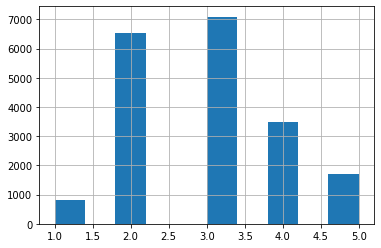

In [10]:
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.,4.5,6.,np.inf],labels=[1,2,3,4,5])
housing["income_cat"].hist()

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

splits = StratifiedShuffleSplit(n_splits=10, test_size=0.2,random_state=42)
# splits is just a holder of information. splits.split produces the actual splits of dataset
for trainIndices, testIndices in splits.split(housing,housing["income_cat"]):
    stratTrainSet = housing.iloc[trainIndices]
    stratTestSet = housing.iloc[testIndices]

In [12]:
for set in (stratTestSet,stratTrainSet):
    set.drop("income_cat", axis=1, inplace=True)
# ********************** housing is trainSet only ************************
housing = stratTrainSet.copy()
trainLabels = stratTrainSet["median_house_value"]
trainAttrs = stratTrainSet.drop("median_house_value",axis=1)
housingAttrsNum = trainAttrs.drop("ocean_proximity",axis=1)

testLabels = stratTestSet["median_house_value"]
testAttrs = stratTestSet.drop("median_house_value",axis=1)

C:\Users\yug\AppData\Local\Temp\ipykernel_15520\389350506.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set.drop("income_cat", axis=1, inplace=True)
C:\Users\yug\AppData\Local\Temp\ipykernel_15520\389350506.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set.drop("income_cat", axis=1, inplace=True)


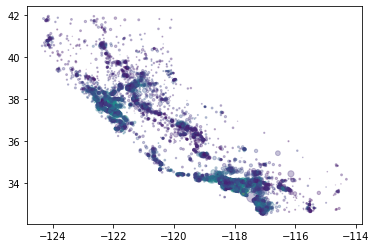

In [13]:
trainIncome = housing["median_income"]
norm = matplotlib.colors.Normalize(vmin=0, vmax=1)
trainIncomeNorm = norm(trainIncome)

plt.scatter(x=housing["longitude"], y=housing["latitude"], alpha=0.3, c=trainIncomeNorm, s=housing["population"]/300)
plt.show()

In [14]:
corrMatrix = housing.corr()
corrMatrix["median_house_value"].sort_values()

C:\Users\yug\AppData\Local\Temp\ipykernel_15520\3365168080.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrMatrix = housing.corr()


latitude             -0.147542
longitude            -0.048020
population            0.013964
housing_median_age    0.066883
total_bedrooms        0.072734
households            0.094433
total_rooms           0.143106
median_income         0.648774
median_house_value    1.000000
Name: median_house_value, dtype: float64

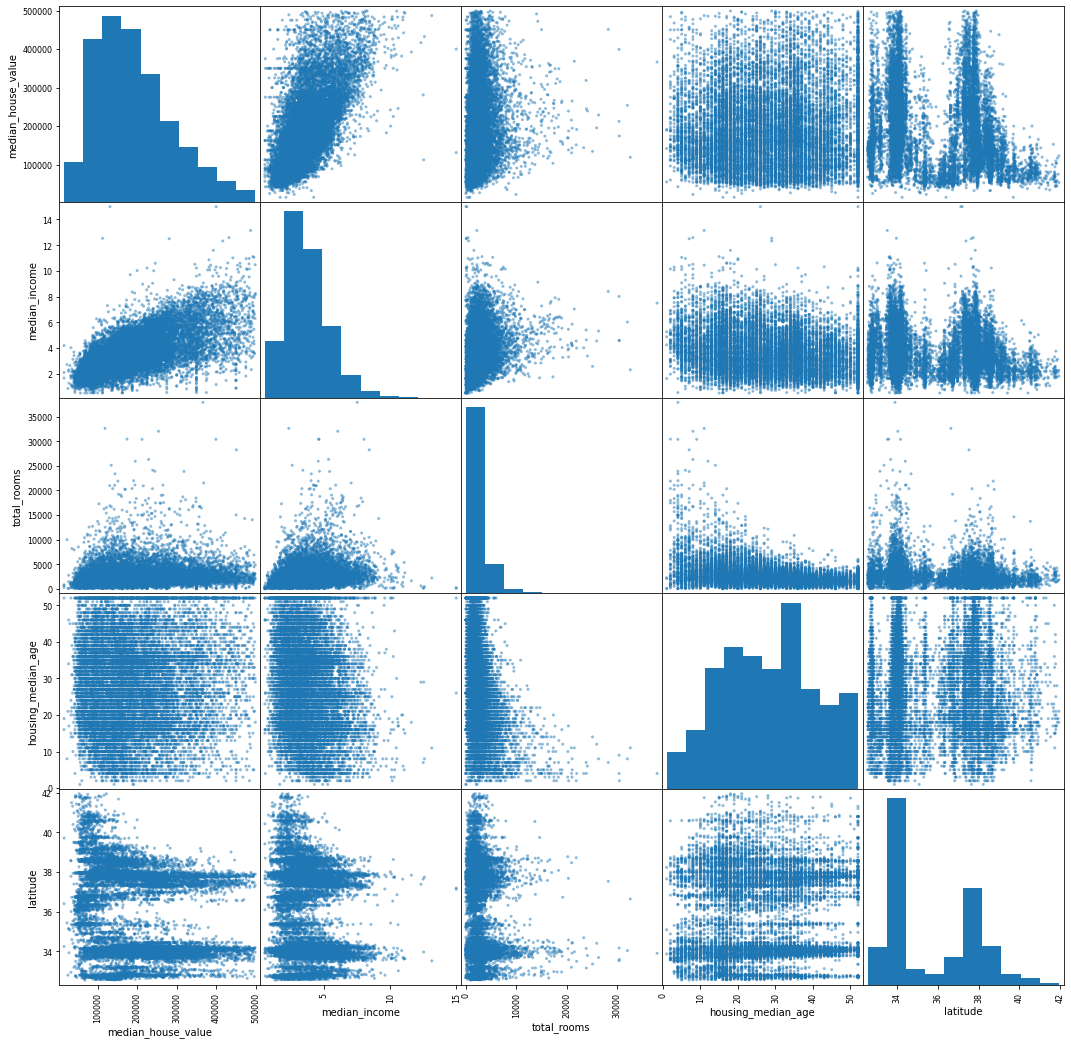

In [15]:
from pandas.plotting import scatter_matrix

attrs = ["median_house_value","median_income","total_rooms","housing_median_age","latitude"]

scatter_matrix(housing[attrs], figsize=(18,18))
plt.show()

In [16]:
housing["roomPerHousehold"] = housing["total_rooms"]/housing["households"]
housing["bedroomPerRoom"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["popPerHousehold"] = housing["population"]/housing["households"]

In [17]:
# Imputing for totalBedrooms as it has NaN values too.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housingNum = housing.drop("ocean_proximity", axis=1)
imputer.fit(housingNum)
transHousing = imputer.transform(housingNum)
transHousing = pd.DataFrame(transHousing,columns=housingNum.columns, index=housingNum.index)


In [18]:
corrMatrix = transHousing.corr()
print(corrMatrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.648774
total_rooms           0.143106
roomPerHousehold      0.109105
households            0.094433
total_bedrooms        0.072510
housing_median_age    0.066883
population            0.013964
popPerHousehold      -0.034298
longitude            -0.048020
latitude             -0.147542
bedroomPerRoom       -0.217675
Name: median_house_value, dtype: float64


In [19]:
# Splitting into train and test sets.
def dropper(dataset,labelName):
    trainSet = dataset.drop(labelName, axis=1)
    trainLabels = dataset[labelName].copy()
    return trainSet,trainLabels

trainSet, trainLabels = dropper(transHousing,"median_house_value")

In [20]:
transHousing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,roomPerHousehold,bedroomPerRoom,popPerHousehold
4174,-118.21,34.10,36.0,2000.0,533.0,1234.0,535.0,3.7437,241700.0,3.738318,0.266500,2.306542
2134,-119.71,36.80,25.0,875.0,156.0,646.0,166.0,3.0000,72800.0,5.271084,0.178286,3.891566
4481,-118.18,34.06,27.0,2025.0,565.0,2189.0,577.0,2.6083,148600.0,3.509532,0.279012,3.793761
20386,-118.93,34.20,17.0,2619.0,606.0,1655.0,557.0,3.8860,281300.0,4.701975,0.231386,2.971275
10291,-117.83,33.87,5.0,6971.0,1449.0,3521.0,1423.0,5.2131,243900.0,4.898805,0.207861,2.474350
...,...,...,...,...,...,...,...,...,...,...,...,...
16734,-122.40,37.68,36.0,3595.0,815.0,1649.0,755.0,3.3816,253400.0,4.761589,0.226704,2.184106
15880,-122.41,37.75,52.0,2452.0,623.0,1932.0,549.0,2.3903,236100.0,4.466302,0.254078,3.519126
12648,-121.47,38.50,17.0,1895.0,424.0,620.0,417.0,1.7188,137500.0,4.544365,0.223747,1.486811
4076,-118.45,34.14,33.0,1741.0,274.0,588.0,267.0,7.9625,490800.0,6.520599,0.157381,2.202247


In [21]:
print(housing[["ocean_proximity"]])
print(housing["ocean_proximity"])
# first is a vector, 2nd is a df series

      ocean_proximity
4174        <1H OCEAN
2134           INLAND
4481        <1H OCEAN
20386       <1H OCEAN
10291       <1H OCEAN
...               ...
16734        NEAR BAY
15880        NEAR BAY
12648          INLAND
4076        <1H OCEAN
9909         NEAR BAY

[15718 rows x 1 columns]
4174     <1H OCEAN
2134        INLAND
4481     <1H OCEAN
20386    <1H OCEAN
10291    <1H OCEAN
           ...    
16734     NEAR BAY
15880     NEAR BAY
12648       INLAND
4076     <1H OCEAN
9909      NEAR BAY
Name: ocean_proximity, Length: 15718, dtype: object


In [22]:
# For encoding ocean Proximity
textData = housing[["ocean_proximity"]] # [[]] gives vector, [] gives pandas series
from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder()
textData_enc = encoder.fit_transform(textData)
print(encoder.categories_)
textData_enc
# Encoded data is in order of .categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


array([[0.],
       [1.],
       [0.],
       ...,
       [1.],
       [0.],
       [3.]])

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
# Mixin creates a fit_transform for us
# Base Estimator gives get_params and set_params which are useful for hyperparameter tuning
Rooms_index,Bedrooms_index,pop_index,household_index = 3,4,5,6
class combinedAttrAdder(BaseEstimator,TransformerMixin):
    
    def __init__(self, addBedroomsPerRoom =  True):
        self.addBedroomsPerRoom = addBedroomsPerRoom
    def fit(self,X,y=None):
        return self
    def transform(self,X,y=None):
        roomsPerHousehold = X[:,Rooms_index]/X[:,household_index]
        popPerHousehold = X[:,pop_index]/X[:,household_index]

        if(self.addBedroomsPerRoom == True):
            bedroomsPerHousehold = X[:,Bedrooms_index]/X[:,household_index]
            return np.c_[X,roomsPerHousehold,popPerHousehold,bedroomsPerHousehold]
        else:
            return np.c_[X,roomsPerHousehold,popPerHousehold]
# creating generalized algos like these help when you're trying out attribute combinations.

SCALING OF FEATURES

 Standardization- (xi-xbar)/(variance)
 Not bounded b/w any 2 values
 more affected by outliers

 Min-max scaling- restricts to 0-1
 Bounded
 less affected by outliers as range is small

 !! Transformers are fit to training sets only and not test or validation sets. This prevents leakage of max-min data and mean,variance,etc.  It may be insignificant for larger datasets, but JIC, we take precautions.


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_Pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("attrAdder", combinedAttrAdder()),
        ("stdScaler",StandardScaler())
    ]
)

numColn = list(housingAttrsNum)
cat_attr = ["ocean_proximity"]
num_cat_Pipeline = ColumnTransformer(
    [
        ("cat", OrdinalEncoder(), cat_attr),
        ("num", num_Pipeline, numColn)
        
    ]
)

housingFinal_labels = trainLabels
#housing = housing.drop("median_house_value", axis=1)
housingFinal = num_cat_Pipeline.fit_transform(trainAttrs)


In [25]:
from sklearn.linear_model import LinearRegression

linReg = LinearRegression()
linReg.fit(housingFinal,housingFinal_labels)

LinearRegression()

In [26]:
testLabels = testLabels
testFinal = num_cat_Pipeline.fit_transform(testAttrs)

In [27]:
from sklearn.metrics import mean_squared_error
preds = linReg.predict(testFinal)

np.sqrt(mean_squared_error(testLabels, preds))

61986.01664266288

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid =[
    {"n_estimators": [3,10,30], "max_features":[2,4,6,8]},
    {"n_estimators": [3,10,30], "max_features":[2,4,6,8], "bootstrap": [False]}
]

forest_reg = RandomForestRegressor()

gridSearch = GridSearchCV(forest_reg, param_grid,cv=5,scoring="neg_mean_squared_error", return_train_score=True)

gridSearch.fit(housingFinal,housingFinal_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [40]:
print(gridSearch.best_estimator_)

RandomForestRegressor(bootstrap=False, max_features=4, n_estimators=30)
